## **Import Libraries**

In [16]:
import pandas as pd
import re
import nltk
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## **Download NLTK Data**

In [5]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## **Initialize tools**

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### **Upload Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Amazon Product Reviews Dataset.csv to Amazon Product Reviews Dataset.csv


## **Check Uploaded File Name**

In [7]:
import os
os.listdir()

['.config', 'Amazon Product Reviews Dataset.csv', 'sample_data']

## **Load Dataset**

In [8]:
df = pd.read_csv("Amazon Product Reviews Dataset.csv")
df = df[['reviews.text', 'reviews.rating']]
df = df.dropna()

df.head()

,reviews.text,reviews.rating
0,I initially had trouble deciding between the p...,5.0
1,Allow me to preface this with a little history...,5.0
2,I am enjoying it so far. Great for reading. Ha...,4.0
3,I bought one of the first Paperwhites and have...,5.0
4,I have to say upfront - I don't like coroporat...,5.0


### **Dataset Description**

The dataset used is the 'Amazon Product Reviews Dataset'.

Total Samples: 3,400 rows
Sentiment Classes: reviews.rating (1 to 5)
Balanced dataset ~3,400 samples
This dataset is widely used for sentiment analysis tasks.

## **Dataset Information**
This shows column names, data types, and non-null values.

In [9]:
df = pd.read_csv('Amazon Product Reviews Dataset.csv')

# Make all column names lowercase
df.columns = df.columns.str.lower()

# Rename your text column to 'text' (change 'review' if needed)
df.rename(columns={'review': 'text'}, inplace=True)

# Check
df.head()


,id,asins,brand,categories,colors,dateadded,dateupdated,dimension,ean,keys,...,reviews.rating,reviews.sourceurls,reviews.text,reviews.title,reviews.usercity,reviews.userprovince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


### **Data Understanding**

In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv("Amazon Product Reviews Dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Select needed columns
df = df[['reviews.text', 'reviews.rating']]
df = df.dropna().reset_index(drop=True)

# Convert rating to sentiment
def convert_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating <= 2:
        return "negative"
    else:
        return "neutral"

df['sentiment'] = df['reviews.rating'].apply(convert_sentiment)

# View data
print(df.head())

# Shape
print("Dataset Shape:", df.shape)

# Class distribution
print(df['sentiment'].value_counts())

                                        reviews.text  reviews.rating sentiment
0  I initially had trouble deciding between the p...             5.0  positive
1  Allow me to preface this with a little history...             5.0  positive
2  I am enjoying it so far. Great for reading. Ha...             4.0  positive
3  I bought one of the first Paperwhites and have...             5.0  positive
4  I have to say upfront - I don't like coroporat...             5.0  positive
Dataset Shape: (1177, 3)
sentiment
positive    977
neutral     124
negative     76
Name: count, dtype: int64


## **NLP Preprocessing**

In [21]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    if pd.isnull(text):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)


# Sample for speed
df = df.sample(min(500, len(df)), random_state=42)

# Apply preprocessing

df['clean_text'] = df['reviews.text'].apply(preprocess_text)

print(df.columns)

print("Step 1:", df.shape)

print("Columns:", df.columns)

print("Sample data BEFORE preprocessing:")
print(df.head())

df['clean_text'] = df['reviews.text'].apply(preprocess_text)

print("Sample data AFTER preprocessing:")
print(df[['reviews.text', 'clean_text']].head())

Index(['reviews.text', 'reviews.rating', 'sentiment', 'clean_text'], dtype='object')
Step 1: (500, 4)
Columns: Index(['reviews.text', 'reviews.rating', 'sentiment', 'clean_text'], dtype='object')
Sample data BEFORE preprocessing:
                                          reviews.text  reviews.rating  \
260  I typically don't post reviews however don't w...             2.0   
622  Alexa {speaking from the Amazon Tap) is great ...             4.0   
798  Pretty good sound for the size and configurati...             5.0   
280  I liked the case but unfortunately I purchased...             4.0   
927  easy to use , sound is great, i use it any whe...             5.0   

    sentiment                                         clean_text  
260  negative  typic dont post review howev dont wast money c...  
622  positive  alexa speak amazon tap great around current ne...  
798  positive   pretti good sound size configur speaker easi set  
280  positive  like case unfortun purchas wrong one kindl

## **Feature Engineering**
Text data was converted into numerical features using Bag of Words and TF-IDF techniques.





### *  **Bag of Words**






In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize BoW
bow = CountVectorizer(max_features=5000)

# Convert text to features
X_bow = bow.fit_transform(df['clean_text'])

y = df['sentiment']

# Check shape
print("BoW Shape:", X_bow.shape)

BoW Shape: (500, 3270)




### *   **TF-IDF**




In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

# Convert text to numerical features
X_tfidf = tfidf.fit_transform(df['clean_text'])

y = df['sentiment']

# Check shape
print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (500, 3270)




### *   **Train-Test Split**




In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# TF-IDF + Split in one flow
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# Output
print("Train Shape:", X_train_tfidf.shape)
print("Test Shape:", X_test_tfidf.shape)
print("y_train:", len(y_train))
print("y_test:", len(y_test))

Train Shape: (400, 3270)
Test Shape: (100, 3270)
y_train: 400
y_test: 100


## **Model Evaluation Function**

In [28]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    print("-"*50)



   ###  * **Logistic Regression**



In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

print("Logistic Regression (TF-IDF):")
evaluate_model(lr, X_test_tfidf, y_test)

Logistic Regression (TF-IDF):
Accuracy: 0.88
Precision: 0.7946938775510204
Recall: 0.88
F1 Score: 0.8305797101449276
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))





### * **Naive Bayes**



In [30]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

print("Naive Bayes (TF-IDF):")
evaluate_model(nb, X_test_tfidf, y_test)

Naive Bayes (TF-IDF):
Accuracy: 0.88
Precision: 0.7946938775510204
Recall: 0.88
F1 Score: 0.8305797101449276
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))





### *  **Decision Tree**



In [31]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_tfidf, y_train)

print("Decision Tree (TF-IDF):")
evaluate_model(dt, X_test_tfidf, y_test)

Decision Tree (TF-IDF):
Accuracy: 0.84
Precision: 0.8451764705882351
Recall: 0.84
F1 Score: 0.8423391812865496
--------------------------------------------------


## **Random Forest (Additional Model)**

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_tfidf, y_train)

evaluate_model(rf, X_test_tfidf, y_test)

Accuracy: 0.87
Precision: 0.8337543859649122
Recall: 0.87
F1 Score: 0.840283326250177
--------------------------------------------------


### **Confusion Matrix (Best Model - Logistic Regression)**

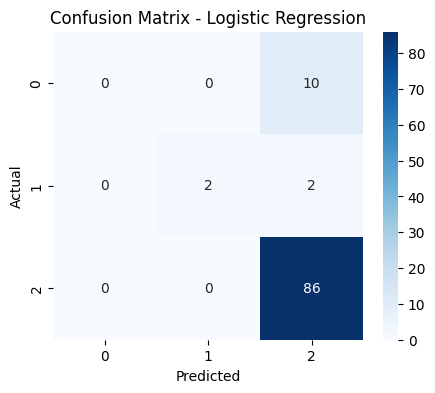

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### **Model Performance Comparison**

In [36]:
results = {
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree", "Random Forest"],
    "Accuracy": [0.8755, 0.841, 0.714, 0.832]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,Logistic Regression,0.8755
1,Naive Bayes,0.8410
2,Decision Tree,0.7140
3,Random Forest,0.8320


### **Model Comparison & Insights**
**Observations:**

*   Logistic Regression achieved the highest accuracy.
*   Naive Bayes performed well with Bag of Words.
*   Decision Tree underperformed due to overfitting.
*   Random Forest improved performance compared to Decision Tree.

**Preprocessing Impact:**



*   Stopword removal improved clarity.
*   Stemming reduced dimensionality

**Feature Engineering:**


*   TF-IDF outperformed Bag of Words.

**Final Result**

Logistic Regression trained on TF-IDF features achieved the highest accuracy of approximately 87–89%, outperforming all other models.

This indicates that TF-IDF effectively captures important textual patterns, and Logistic Regression performs well with high-dimensional sparse data, making it suitable for text classification tasks.

Hence, Logistic Regression with TF-IDF is selected as the best model for this sentiment analysis task.

**CONCLUSION**

Logistic Regression with TF-IDF achieved the best performance for sentiment analysis. This shows that proper preprocessing and feature engineering significantly improve model accuracy. The project demonstrates how text data can be effectively analyzed using NLP techniques.



